##If your IDE doesn't add a venv or .venv automatically:
python -m venv venv

source venv/Scripts/activate (Windows: venv/Scripts/activate)

pip install -r requirements.txt

pip freeze > requirements.txt

##After installing Docker Desktop:
docker compose up -d

In [1]:
import pandas as pd
from pymongo import MongoClient

In [2]:
def ingest_csv(csv_path, db_name, collection_name, sep=';', encoding='utf-8'):
    client = MongoClient("mongodb://localhost:27017/")
    db = client[db_name]
    collection = db[collection_name]

    try:
        df = pd.read_csv(
            csv_path,
            sep=sep,
            dtype=str,
            encoding=encoding,
            keep_default_na=False,
        )

        if df.empty:
            print("The CSV file is empty.")
            return

        # Data Cleaning
        # MongoDB does not accept float 'NaN'. Also convert empty strings to None (null).
        df = df.where(pd.notnull(df), None)
        df = df.replace({"": None})

        # Convert to list of dictionaries
        data_dict = df.to_dict('records')

        # Insert into MongoDB
        if data_dict:
            collection.drop()
            result = collection.insert_many(data_dict)
            print(f"Successfully inserted {len(result.inserted_ids)} records from {csv_path}.")
        else:
            print("File is empty.")

    except Exception as e:
        print(f"An error occurred: {e}")
    finally:
        client.close()

In [3]:
ingest_csv(
        csv_path="raw_data/birthrate/OGD_indquot001_HVD_INDQUOTE_3.csv", 
        db_name="mongo_db", 
        collection_name="raw_birthrate"
    )

Successfully inserted 1104 records from raw_data/birthrate/OGD_indquot001_HVD_INDQUOTE_3.csv.


In [4]:
ingest_csv(
        csv_path="raw_data/fertility/OGD_indquot001_HVD_INDQUOTE_6.csv", 
        db_name="mongo_db", 
        collection_name="raw_fertility_rate"
    )

Successfully inserted 1104 records from raw_data/fertility/OGD_indquot001_HVD_INDQUOTE_6.csv.


In [5]:
def ingest_ods(file_path, db_name, collection_name, sheet_name=None, drop_rows=None):
    client = MongoClient("mongodb://localhost:27017/")
    db = client[db_name]
    collection = db[collection_name]

    try:
        resolved_sheet = 0 if sheet_name is None else sheet_name
        df = pd.read_excel(
            file_path,
            engine='odf',
            header=None,
            sheet_name=resolved_sheet,
        )

        if drop_rows is None:
            drop_rows_resolved = []
        elif isinstance(drop_rows, int):
            drop_rows_resolved = [drop_rows]
        else:
            drop_rows_resolved = list(drop_rows)

        # Drop selected rows (0-based indices) before header normalization
        if drop_rows_resolved:
            df = df.drop(index=drop_rows_resolved, errors='ignore').reset_index(drop=True)

        # Use the (remaining) first row as header
        header = df.iloc[0].fillna("").astype(str).str.strip()
        df = df.iloc[1:].copy()
        df.columns = header

        # Drop the last two data rows
        df = df.iloc[:-2].copy().reset_index(drop=True)

        # Data Cleaning
        # MongoDB does not accept float 'NaN'. Convert them to None (null).
        df = df.where(pd.notnull(df), None)

        # Convert DataFrame to dictionary records
        data_dict = df.to_dict("records")

        # Insert into MongoDB
        if data_dict:
            collection.drop()
            result = collection.insert_many(data_dict)
            print(f"Successfully inserted {len(result.inserted_ids)} records from {file_path}.")
        else:
            print("File is empty.")

    except Exception as e:
        print(f"An error occurred: {e}")
    finally:
        client.close()

In [6]:
ingest_ods(
        file_path="raw_data/Gross_Regional_Product_NUTS3.ods", 
        db_name="mongo_db", 
        collection_name="raw_GRP", 
        sheet_name="GRP",
        drop_rows=(0, 2)
    )

Successfully inserted 36 records from raw_data/Gross_Regional_Product_NUTS3.ods.


In [7]:
ingest_ods(
        file_path="raw_data/Gross_Regional_Product_NUTS3.ods", 
        db_name="mongo_db", 
        collection_name="raw_GRP_per_capita", 
        sheet_name="GRP_per_capita",
        drop_rows=(0, 2)
    )

Successfully inserted 36 records from raw_data/Gross_Regional_Product_NUTS3.ods.


In [8]:
ingest_ods(
        file_path="raw_data/HPIMesszahlen.ods", 
        db_name="mongo_db", 
        collection_name="raw_HPI", 
        sheet_name=None,
        drop_rows=(0, 2)
    )

Successfully inserted 79 records from raw_data/HPIMesszahlen.ods.


In [9]:
def ingest_ods_chunk(file_path, db_name, collection_name, skiprows, nrows, usecols, col_names):
    """
    Liest einen spezifischen Block (Chunk) aus einer ODS-Datei und speichert ihn in MongoDB.
    Perfekt für vertikal gestapelte Tabellen (wie Erwerbstätigenquoten).
    """
    client = MongoClient("mongodb://localhost:27017/")
    db = client[db_name]
    collection = db[collection_name]

    try:
        # Lade nur den exakt definierten Bereich aus der Excel-Tabelle
        df = pd.read_excel(
            file_path,
            engine='odf',
            skiprows=skiprows,
            nrows=nrows,
            usecols=usecols,
            names=col_names,
            header=None
        )

        if df.empty:
            print(f"The extracted chunk for {collection_name} is empty.")
            return

        # --- Data Cleaning ---
        # 1. Wir erzwingen, dass das 'Jahr' eine Zahl ist. Text-Fußnoten werden dadurch zu 'NaN' (Not a Number)
        df["Jahr"] = pd.to_numeric(df["Jahr"], errors="coerce")
        
        # 2. Wir löschen alle Zeilen, in denen das Jahr 'NaN' ist (das putzt alle leeren Zeilen weg)
        df = df.dropna(subset=["Jahr"])

        # 3. MongoDB mag keine Float-'NaN's. Wir wandeln sie in None (Null) um
        df = df.where(pd.notnull(df), None)

        # Convert DataFrame to dictionary records
        data_dict = df.to_dict("records")

        # Insert into MongoDB
        if data_dict:
            collection.drop() # Alte Daten überschreiben, falls Zelle nochmal ausgeführt wird
            result = collection.insert_many(data_dict)
            print(f"Successfully inserted {len(result.inserted_ids)} records into '{collection_name}'.")
        else:
            print(f"No valid records found to insert for '{collection_name}'.")

    except Exception as e:
        print(f"An error occurred: {e}")
    finally:
        client.close()

In [10]:
# Dateipfad zur ODS-Datei
file_erwerb = "raw_data/Tab2_erwerbstaetigenquoten_nach_alter_und_geschlecht_seit_1994.ods"

# 1. Daten für "Zusammen" (Männer und Frauen)
# Nimmt Spalte A (0) für das Jahr und Spalte B (1) für die Quote
ingest_ods_chunk(
    file_path=file_erwerb,
    db_name="mongo_db",
    collection_name="raw_emp_zusammen",
    skiprows=4,          # Überspringe den ersten Header-Müll
    nrows=31,            # Lese die 31 Jahre ein
    usecols=[0, 1],      # Spalten A und B
    col_names=["Jahr", "Quote_Zusammen"]
)

# 2. Daten für "Männer"
ingest_ods_chunk(
    file_path=file_erwerb,
    db_name="mongo_db",
    collection_name="raw_emp_maenner",
    skiprows=36,         # Überspringe bis zum Männer-Block (BITTE IN EXCEL PRÜFEN!)
    nrows=31, 
    usecols=[0, 1], 
    col_names=["Jahr", "Quote_Maenner"]
)

# 3. Daten für "Frauen"
ingest_ods_chunk(
    file_path=file_erwerb,
    db_name="mongo_db",
    collection_name="raw_emp_frauen",
    skiprows=68,         # Überspringe bis zum Frauen-Block (BITTE IN EXCEL PRÜFEN!)
    nrows=31, 
    usecols=[0, 1], 
    col_names=["Jahr", "Quote_Frauen"]
)

Successfully inserted 31 records into 'raw_emp_zusammen'.
Successfully inserted 31 records into 'raw_emp_maenner'.
Successfully inserted 31 records into 'raw_emp_frauen'.


In [11]:
file_arbeitslos = "raw_data/Tab8_vorgemerkte_arbeitslose_und_arbeitslosenquoten_na.ods"

# --- 1. Arbeitslosenquote "Zusammen" ---
# Wir lesen Spalte A (0) für das Jahr und Spalte E (4) für die Quote Zusammen
ingest_ods_chunk(
    file_path=file_arbeitslos,
    db_name="mongo_db",
    collection_name="raw_unemp_zusammen",
    skiprows=4,          # Die ersten 4 Zeilen (Header-Chaos) ignorieren wir
    nrows=31,            # 1994 bis 2024 sind 31 Jahre
    usecols=[0, 4],      # Spalten A und E
    col_names=["Jahr", "Arbeitslosenquote_Zusammen"]
)

# --- 2. Arbeitslosenquote "Männer" ---
# Wir lesen Spalte A (0) für das Jahr und Spalte F (5) für die Quote der Männer
ingest_ods_chunk(
    file_path=file_arbeitslos,
    db_name="mongo_db",
    collection_name="raw_unemp_maenner",
    skiprows=4,          # Daten starten wieder in Zeile 5
    nrows=31, 
    usecols=[0, 5],      # Spalten A und F
    col_names=["Jahr", "Arbeitslosenquote_Maenner"]
)

# --- 3. Arbeitslosenquote "Frauen" ---
# Wir lesen Spalte A (0) für das Jahr und Spalte G (6) für die Quote der Frauen
ingest_ods_chunk(
    file_path=file_arbeitslos,
    db_name="mongo_db",
    collection_name="raw_unemp_frauen",
    skiprows=4,          # Daten starten wieder in Zeile 5
    nrows=31, 
    usecols=[0, 6],      # Spalten A und G
    col_names=["Jahr", "Arbeitslosenquote_Frauen"]
)

Successfully inserted 31 records into 'raw_unemp_zusammen'.
Successfully inserted 31 records into 'raw_unemp_maenner'.
Successfully inserted 31 records into 'raw_unemp_frauen'.


---

## Setup and Database Connection

The following cell imports the required libraries, establishes a connection to the local MongoDB instance, and defines helper functions for loading and saving collections. These helper functions are used throughout the notebook to keep the code concise and consistent.

In [12]:
import pandas as pd
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["mongo_db"]


def load_collection(name):
    df = pd.DataFrame(list(db[name].find()))
    if "_id" in df.columns:
        df = df.drop(columns="_id")
    return df


def save_collection(df, collection_name):
    collection = db[collection_name]
    collection.drop()
    collection.insert_many(df.to_dict("records"))
    print(f"Saved {collection_name} to MongoDB.")

## Data Inspection and Understanding

Before performing any analysis, it is essential to understand the structure and content of the datasets stored in MongoDB. This step helps identify:

- Available variables (columns)
- Data types and potential issues (e.g. numeric values stored as strings)
- Missing or inconsistent values
- Overall size and structure of each dataset

The following code loads each collection from the MongoDB database into a pandas DataFrame and prints:

- Column names → to understand available variables
- First rows → to inspect how the data is structured
- DataFrame info → to check data types and missing values
- Shape → to understand dataset size

This step forms the basis for all further data cleaning and analysis.

In [13]:
collections = [
    "raw_GRP",
    "raw_GRP_per_capita",
    "raw_HPI",
    "raw_birthrate",
    "raw_emp_zusammen",
    "raw_emp_maenner",
    "raw_emp_frauen",
    "raw_unemp_zusammen",
    "raw_unemp_maenner",
    "raw_unemp_frauen",
    "raw_fertility_rate"
]

for name in collections:
    print("=" * 60)
    print(f"COLLECTION: {name}")
    print("=" * 60)

    df = load_collection(name)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst and last 5 rows:")
    print(df.head())
    print("")
    print(df.tail())

    print("\nInfo:")
    df.info()

    print("\nShape:", df.shape)
    print("\n\n")

COLLECTION: raw_GRP

Columns:
['NUTS-Code', 'Region', '2000', '2001.0', '2002.0', '2003.0', '2004.0', '2005.0', '2006.0', '2007.0', '2008.0', '2009.0', '2010.0', '2011.0', '2012.0', '2013.0', '2014.0', '2015.0', '2016.0', '2017.0', '2018.0', '2019.0', '2020.0', '2021.0', '2022.0', '2023.0']

First and last 5 rows:
  NUTS-Code                   Region    2000    2001.0    2002.0    2003.0  \
0        AT                  Austria  212407  219373.0  225088.0  230542.0   
1     AT111         Mittelburgenland     572     611.0     599.0     636.0   
2     AT112           Nordburgenland    2600    2660.0    2785.0    2847.0   
3     AT113            Südburgenland    1728    1761.0    1821.0    1777.0   
4     AT121  Mostviertel-Eisenwurzen    4558    4699.0    4741.0    4826.0   

     2004.0    2005.0    2006.0    2007.0  ...    2014.0    2015.0    2016.0  \
0  240542.0  252355.0  265934.0  282208.0  ...  330113.0  342084.0  355666.0   
1     645.0     666.0     703.0     747.0  ...     853.

## Cleaning the Birth Rate Dataset

The raw birth rate dataset is stored in long format and already contains the essential analytical dimensions: year, region, and value. However, these fields are still encoded in a non-standard way and must be cleaned before analysis.

The following cleaning steps are performed:

1. The raw collection is loaded from MongoDB.
2. The year is extracted from strings such as `DEMIND_ZEIT-2002`.
3. The regional code is simplified from values such as `GRNU-AT111` to `AT111`.
4. The birth rate values are converted from strings with comma decimal separators (for example `7,260`) into numeric values.
5. The cleaned columns are renamed to more readable names.

This produces a structured dataset that can be used for filtering, grouping, visualization, and later merging with other regional datasets.

In [14]:
birthrate = load_collection("raw_birthrate").copy()

birthrate["year"] = birthrate["C-DEMIND_ZEIT-0"].str.extract(r"(\d{4})").astype("Int64")
birthrate["NUTS-Code"] = birthrate["C-DEMIND_NUTS3-0"].str.replace("GRNU-", "", regex=False)
birthrate["birth_rate"] = pd.to_numeric(
    birthrate["F-DEMIND_CBR"].str.replace(",", ".", regex=False),
    errors="coerce"
)

birthrate = birthrate[birthrate["NUTS-Code"].str.len() == 5]

birthrate_clean = birthrate[["NUTS-Code", "year", "birth_rate"]].copy()
birthrate_clean = birthrate_clean.sort_values(["NUTS-Code", "year"]).reset_index(drop=True)

print(birthrate_clean.head())
birthrate_clean.info()
print(birthrate_clean.isna().sum())
print(birthrate_clean.shape)

  NUTS-Code  year  birth_rate
0     AT111  2002       7.260
1     AT111  2003       6.693
2     AT111  2004       7.744
3     AT111  2005       7.265
4     AT111  2006       6.942
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805 entries, 0 to 804
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   NUTS-Code   805 non-null    object 
 1   year        805 non-null    Int64  
 2   birth_rate  805 non-null    float64
dtypes: Int64(1), float64(1), object(1)
memory usage: 19.8+ KB
NUTS-Code     0
year          0
birth_rate    0
dtype: int64
(805, 3)


## Storing the Cleaned Birth Rate Dataset

After cleaning and validating the birth rate data, the resulting dataset is stored in MongoDB as a new collection named `clean_birthrate`. This preserves the cleaned version separately from the original raw data and makes it available for later analysis.

In [15]:
save_collection(birthrate_clean, "clean_birthrate")

Saved clean_birthrate to MongoDB.


## Cleaning the Total Fertility Rate Dataset

The total fertility rate dataset is stored in long format and already contains the essential analytical dimensions: year, region, and value. However, these fields are still encoded in a non-standard way and must be cleaned before analysis.

The following cleaning steps are performed:

1. The raw collection is loaded from MongoDB.
2. The year is extracted from strings such as `DEMIND_ZEIT-2002`.
3. The regional code is simplified from values such as `GRNU-AT111` to `AT111`.
4. The fertility rate values are converted from strings with comma decimal separators (for example `7,260`) into numeric values.
5. The cleaned columns are renamed to more readable names.

This produces a structured dataset that can be used for filtering, grouping, visualization, and later merging with other regional datasets.

In [17]:
fertility = load_collection("raw_fertility_rate").copy()

# Reinigung analog zur Birth Rate
fertility["year"] = fertility["C-DEMIND_ZEIT-0"].str.extract(r"(\d{4})").astype("Int64")
fertility["NUTS-Code"] = fertility["C-DEMIND_NUTS3-0"].str.replace("GRNU-", "", regex=False)

# ACHTUNG: Hier den genauen Spaltennamen der TFR-Werte aus der neuen CSV einsetzen!
fertility["TFR"] = pd.to_numeric(
    fertility["F-DEMIND_TFR"].str.replace(",", ".", regex=False), # fiktiver Spaltenname
    errors="coerce"
)

fertility_clean = fertility[fertility["NUTS-Code"].str.len() == 5][["NUTS-Code", "year", "TFR"]].copy()
fertility_clean = fertility_clean.sort_values(["NUTS-Code", "year"]).dropna().reset_index(drop=True)

print(fertility_clean.head())
fertility_clean.info()
print(fertility_clean.isna().sum())
print(fertility_clean.shape)

  NUTS-Code  year    TFR
0     AT111  2002  1.199
1     AT111  2003  1.122
2     AT111  2004  1.308
3     AT111  2005  1.245
4     AT111  2006  1.209
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805 entries, 0 to 804
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   NUTS-Code  805 non-null    object 
 1   year       805 non-null    Int64  
 2   TFR        805 non-null    float64
dtypes: Int64(1), float64(1), object(1)
memory usage: 19.8+ KB
NUTS-Code    0
year         0
TFR          0
dtype: int64
(805, 3)


## Storing the Cleaned Fertility Rate Dataset

After cleaning and validating the fertility rate data, the resulting dataset is stored in MongoDB as a new collection named `clean_fertility_rate`. This preserves the cleaned version separately from the original raw data and makes it available for later analysis.

In [18]:
# In MongoDB speichern
save_collection(fertility_clean, "clean_fertility_rate")

Saved clean_fertility_rate to MongoDB.


## Cleaning the GRP Dataset

The raw GRP dataset is stored in wide format, meaning that each year is represented as a separate column. While this format is useful for display, it is not ideal for analysis or merging with other datasets.

To prepare the data for analysis, the dataset is transformed into long format. In the cleaned version, each row represents one observation for a specific region and year.

The following cleaning steps are performed:

1. The raw collection is loaded from MongoDB.
2. Year column names are standardized by removing the `.0` suffix.
3. The dataset is transformed from wide format to long format.
4. The year and GRP values are converted to numeric types.
5. Missing values are removed.
6. Aggregated regions (such as Austria as a whole, e.g. `AT`) are removed to ensure consistency with other datasets that use NUTS3 regional codes.
7. The cleaned dataset is sorted for readability and later merging.

This produces a structured regional time series dataset at the NUTS3 level that can be combined with other cleaned datasets such as the birth rate data.

In [19]:
grp = load_collection("raw_GRP").copy()

# standardize year column names
grp.columns = [col.replace(".0", "") for col in grp.columns]

# transform from wide to long format
grp_clean = grp.melt(
    id_vars=["NUTS-Code", "Region"],
    var_name="year",
    value_name="GRP"
)

# convert to numeric
grp_clean["year"] = pd.to_numeric(grp_clean["year"], errors="coerce").astype("Int64")
grp_clean["GRP"] = pd.to_numeric(grp_clean["GRP"], errors="coerce")

# remove missing values
grp_clean = grp_clean.dropna(subset=["year", "GRP"])

# keep only NUTS3 regions
grp_clean = grp_clean[grp_clean["NUTS-Code"].str.len() == 5]

# sort rows
grp_clean = grp_clean.sort_values(["NUTS-Code", "year"]).reset_index(drop=True)

print(grp_clean.head())
grp_clean.info()
print(grp_clean.isna().sum())
print(grp_clean.shape)

  NUTS-Code            Region  year    GRP
0     AT111  Mittelburgenland  2000  572.0
1     AT111  Mittelburgenland  2001  611.0
2     AT111  Mittelburgenland  2002  599.0
3     AT111  Mittelburgenland  2003  636.0
4     AT111  Mittelburgenland  2004  645.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   NUTS-Code  840 non-null    object 
 1   Region     840 non-null    object 
 2   year       840 non-null    Int64  
 3   GRP        840 non-null    float64
dtypes: Int64(1), float64(1), object(2)
memory usage: 27.2+ KB
NUTS-Code    0
Region       0
year         0
GRP          0
dtype: int64
(840, 4)


## Storing the Cleaned GRP Dataset

After cleaning and restructuring the GRP data, the resulting dataset is stored in MongoDB as a new collection named `clean_GRP`. This preserves the cleaned version separately from the raw input data and allows it to be reused in later analysis steps.

In [20]:
save_collection(grp_clean, "clean_GRP")

Saved clean_GRP to MongoDB.


## Cleaning the GRP per Capita Dataset

The raw GRP per capita dataset is stored in wide format, meaning that each year is represented as a separate column. While this format is suitable for display, it is not ideal for statistical analysis or for merging with other datasets.

To prepare the data for analysis, the dataset is transformed into long format. In the cleaned version, each row represents one observation for a specific region and year.

The following cleaning steps are performed:

1. The raw collection is loaded from MongoDB.
2. Year column names are standardized by removing the `.0` suffix.
3. The dataset is transformed from wide format to long format.
4. The year and GRP per capita values are converted to numeric types.
5. Missing values are removed.
6. Aggregated regions (such as Austria as a whole, e.g. `AT`) are removed to ensure consistency with other datasets that use NUTS3 regional codes.
7. The cleaned dataset is sorted for readability and later merging.

This produces a structured regional time series dataset at the NUTS3 level that can be combined with other cleaned datasets such as birth rate and GRP.

In [21]:
grp_pc = load_collection("raw_GRP_per_capita").copy()

# standardize year column names
grp_pc.columns = [col.replace(".0", "") for col in grp_pc.columns]

# transform from wide to long format
grp_pc_clean = grp_pc.melt(
    id_vars=["NUTS-Code", "Region"],
    var_name="year",
    value_name="GRP_per_capita"
)

# convert to numeric
grp_pc_clean["year"] = pd.to_numeric(grp_pc_clean["year"], errors="coerce").astype("Int64")
grp_pc_clean["GRP_per_capita"] = pd.to_numeric(grp_pc_clean["GRP_per_capita"], errors="coerce")

# remove missing values
grp_pc_clean = grp_pc_clean.dropna(subset=["year", "GRP_per_capita"])

# keep only NUTS3 regions
grp_pc_clean = grp_pc_clean[grp_pc_clean["NUTS-Code"].str.len() == 5]

# sort rows
grp_pc_clean = grp_pc_clean.sort_values(["NUTS-Code", "year"]).reset_index(drop=True)

print(grp_pc_clean.head())
grp_pc_clean.info()
print(grp_pc_clean.isna().sum())
print(grp_pc_clean.shape)

  NUTS-Code            Region  year  GRP_per_capita
0     AT111  Mittelburgenland  2000         15000.0
1     AT111  Mittelburgenland  2001         16100.0
2     AT111  Mittelburgenland  2002         15900.0
3     AT111  Mittelburgenland  2003         16900.0
4     AT111  Mittelburgenland  2004         17200.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NUTS-Code       840 non-null    object 
 1   Region          840 non-null    object 
 2   year            840 non-null    Int64  
 3   GRP_per_capita  840 non-null    float64
dtypes: Int64(1), float64(1), object(2)
memory usage: 27.2+ KB
NUTS-Code         0
Region            0
year              0
GRP_per_capita    0
dtype: int64
(840, 4)


## Storing the Cleaned GRP per Capita Dataset

After cleaning and restructuring the GRP per capita data, the resulting dataset is stored in MongoDB as a new collection named `clean_GRP_per_capita`. This preserves the cleaned version separately from the raw input data and makes it available for later analysis steps.

In [22]:
save_collection(grp_pc_clean, "clean_GRP_per_capita")

Saved clean_GRP_per_capita to MongoDB.


## Cleaning the Housing Price Index (HPI) Dataset

The raw HPI dataset contains time series data for housing price indices. Unlike the GRP datasets, it is not structured by regions but by time periods such as quarters and yearly averages.

The first column contains the time information but is currently unnamed. Additionally, the dataset includes multiple index categories (e.g. overall index, new housing, existing housing).

The following cleaning steps are performed:

1. The raw collection is loaded from MongoDB.
2. The unnamed first column is renamed to `Period`.
3. Only valid time observations (e.g. quarterly values) are retained, while summary rows (such as yearly averages) are removed.
4. The dataset is transformed into long format, where each row represents one observation for a specific period and index type.
5. The values are converted to numeric types.
6. The cleaned dataset is sorted for readability.

This produces a structured time series dataset that can be used for trend analysis of housing prices.

In [23]:
hpi = load_collection("raw_HPI").copy()

# 1. Unbenannte Spalte umbenennen
hpi = hpi.rename(columns={hpi.columns[0]: "Period"})

print("Raw HPI:")
print(hpi.head())

# 2. FILTERN: Wir behalten NUR die Zeilen, in denen "Jahresdurchschnitt" steht
hpi = hpi[hpi["Period"].str.contains("Jahresdurchschnitt", na=False)].copy()

# 3. Jahr als Zahl extrahieren (z.B. aus "Jahresdurchschnitt 2010" wird 2010)
hpi["Jahr"] = hpi["Period"].str.extract(r"(\d{4})").astype(int)

# Die alte "Period"-Textspalte brauchen wir jetzt nicht mehr, wir werfen sie weg
hpi = hpi.drop(columns=["Period"])

# 4. UMWANDELN (Reshape to long format)
# Wir nutzen jetzt "Jahr" als unsere ID-Spalte!
hpi_clean = hpi.melt(
    id_vars=["Jahr"],
    var_name="HPI_type",
    value_name="HPI"
)

# 5. Werte in numerische Zahlen umwandeln
hpi_clean["HPI"] = pd.to_numeric(hpi_clean["HPI"], errors="coerce")

# 6. Fehlende Werte löschen
hpi_clean = hpi_clean.dropna(subset=["HPI"])

# 7. Sortieren nach Typ und dann nach Jahr
hpi_clean = hpi_clean.sort_values(["HPI_type", "Jahr"]).reset_index(drop=True)

print("\nCleaned HPI (Nur Jahresdurchschnitte):")
print(hpi_clean.head())
print("\nInfo:")
hpi_clean.info()
print("\nMissing Values:")
print(hpi_clean.isna().sum())
print("\nShape:", hpi_clean.shape)

Raw HPI:
                    Period  Gesamtindex HPI  Neuer Wohnraum  \
0                  2010 Q1            97.06           98.81   
1                  2010 Q2            99.85           99.75   
2                  2010 Q3           101.12           99.88   
3                  2010 Q4           101.96          101.55   
4  Jahresdurchschnitt 2010           100.00          100.00   

   Bestehender Wohnraum  Bestehende Häuser  Bestehende Wohnungen  
0                 96.33              96.51                 96.16  
1                 99.89             100.95                 98.88  
2                101.64             100.56                102.68  
3                102.14             101.98                102.29  
4                100.00             100.00                100.00  

Cleaned HPI (Nur Jahresdurchschnitte):
   Jahr           HPI_type     HPI
0  2010  Bestehende Häuser  100.00
1  2011  Bestehende Häuser  103.65
2  2012  Bestehende Häuser  108.55
3  2013  Bestehende Häuser  11

## Storing the Cleaned HPI Dataset

After cleaning and restructuring the HPI data, the resulting dataset is stored in MongoDB as a new collection named `clean_HPI`. This allows the cleaned time series to be reused in later analysis.

In [24]:
save_collection(hpi_clean, "clean_HPI")

Saved clean_HPI to MongoDB.


## Integrating and Formatting the Unemployment Rate Dataset

Thanks to the customized chunk-based import function used in the previous step, the raw data is already free of misaligned headers, missing values, and duplicate rows. 

The remaining data preparation steps are straightforward:
1. Load the three separate collections (Total, Men, Women) from MongoDB.
2. Merge them into a single, unified DataFrame based on the year (`Jahr`).
3. Ensure that all rate columns are explicitly converted to numeric (float) types for analysis.
4. Sort the dataset chronologically and save it as a clean collection.

This approach results in a consolidated, analysis-ready dataset.

In [25]:
# 1. Load the three separate collections
unemp_zus = load_collection("raw_unemp_zusammen")
unemp_m = load_collection("raw_unemp_maenner")
unemp_w = load_collection("raw_unemp_frauen")

print("Raw Total Unemployment (First 3 rows):")
print(unemp_zus.head(3))

# 2. Merge into a single DataFrame based on "Jahr"
unemp_clean = unemp_zus.merge(unemp_m, on="Jahr", how="inner")
unemp_clean = unemp_clean.merge(unemp_w, on="Jahr", how="inner")

# 3. Ensure all quote columns are proper numeric floats
quote_columns = [
    "Arbeitslosenquote_Zusammen", 
    "Arbeitslosenquote_Maenner", 
    "Arbeitslosenquote_Frauen"
]

for col in quote_columns:
    unemp_clean[col] = pd.to_numeric(unemp_clean[col], errors="coerce")

# 4. Sort by year to ensure correct time series order
unemp_clean = unemp_clean.sort_values("Jahr").reset_index(drop=True)

print("\nCleaned & Unified Unemployment Rate:")
print(unemp_clean.head())
print("\nInfo:")
unemp_clean.info()

Raw Total Unemployment (First 3 rows):
   Jahr  Arbeitslosenquote_Zusammen
0  1994                         6.5
1  1995                         6.6
2  1996                         7.0

Cleaned & Unified Unemployment Rate:
   Jahr  Arbeitslosenquote_Zusammen  Arbeitslosenquote_Maenner  \
0  1994                         6.5                        6.4   
1  1995                         6.6                        6.4   
2  1996                         7.0                        6.9   
3  1997                         7.1                        6.9   
4  1998                         7.2                        6.9   

   Arbeitslosenquote_Frauen  
0                       6.7  
1                       6.8  
2                       7.3  
3                       7.4  
4                       7.5  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      ---

## Storing the Cleaned Unemployment Rate Dataset

After cleaning and validating the unemployment rate data, the resulting dataset is stored in MongoDB as a new collection named `clean_unemployment_rate`. This preserves the cleaned version separately from the original raw data and makes it available for later analysis.

In [26]:
save_collection(unemp_clean, "clean_unemployment_rate")

Saved clean_unemployment_rate to MongoDB.


## Integrating and Formatting the Employment Rate Dataset

Thanks to the customized chunk-based import function used in the previous step, the raw data is already free of misaligned headers, missing values, and duplicate rows. 

The remaining data preparation steps are straightforward:
1. Load the three separate collections (Total, Men, Women) from MongoDB.
2. Merge them into a single, unified DataFrame based on the year (`Jahr`).
3. Ensure that all rate columns are explicitly converted to numeric (float) types for analysis.
4. Sort the dataset chronologically and save it as a clean collection.

This approach results in a consolidated, analysis-ready dataset.

In [27]:
# 1. Load the three separate collections from MongoDB
emp_zus = load_collection("raw_emp_zusammen")
emp_m = load_collection("raw_emp_maenner")
emp_w = load_collection("raw_emp_frauen")

print("Raw Total Employment (First 3 rows):")
print(emp_zus.head(3))

# 2. Merge into a single DataFrame based on "Jahr"
emp_clean = emp_zus.merge(emp_m, on="Jahr", how="inner")
emp_clean = emp_clean.merge(emp_w, on="Jahr", how="inner")

# 3. Ensure all quote columns are proper numeric floats
quote_columns = [
    "Quote_Zusammen", 
    "Quote_Maenner", 
    "Quote_Frauen"
]

for col in quote_columns:
    emp_clean[col] = pd.to_numeric(emp_clean[col], errors="coerce")

# 4. Sort by year to ensure correct time series order
emp_clean = emp_clean.sort_values("Jahr").reset_index(drop=True)

print("\nCleaned & Unified Employment Rate:")
print(emp_clean.head())
print("\nInfo:")
emp_clean.info()

Raw Total Employment (First 3 rows):
   Jahr  Quote_Zusammen
0  1994            57.0
1  1995            57.1
2  1996            56.2

Cleaned & Unified Employment Rate:
   Jahr  Quote_Zusammen  Quote_Maenner  Quote_Frauen
0  1994            57.0           68.3          46.7
1  1995            57.1           68.5          46.6
2  1996            56.2           67.2          46.1
3  1997            56.1           66.9          46.3
4  1998            56.0           66.6          46.4

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Jahr            31 non-null     int64  
 1   Quote_Zusammen  31 non-null     float64
 2   Quote_Maenner   31 non-null     float64
 3   Quote_Frauen    31 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 1.1 KB


## Storing the Cleaned Employment Rate Dataset

After cleaning and validating the employment rate data, the resulting dataset is stored in MongoDB as a new collection named `clean_employment_rate`. This preserves the cleaned version separately from the original raw data and makes it available for later analysis.

In [28]:
save_collection(emp_clean, "clean_employment_rate")

Saved clean_employment_rate to MongoDB.


## Creating a National Master Dataset for Austria

To analyze macroeconomic and demographic trends on a national level, we need to consolidate our cleaned datasets into a single master table. 

The following steps are performed:
1. **Filtering for National Averages:** Regional datasets (GRP, Birth Rate) are filtered for the national codes (`AT` for GRP, `AT0` for Birth Rate).
2. **Selecting Core Indicators:** From the HPI dataset, only the overall index (`Gesamtindex HPI`) is retained.
3. **Standardizing the Time Dimension:** The time columns (e.g., `Jahr` in the employment and HPI datasets) are renamed to a uniform `year` column.
4. **Merging:** All datasets are joined into a single, comprehensive DataFrame using an inner merge on the `year` column.
5. **Storage:** The consolidated master dataset is saved to MongoDB for final analysis.

In [30]:
# 1. GRP: Österreich ("AT") aus den Rohdaten laden
raw_grp = load_collection("raw_GRP")
at_grp = raw_grp[raw_grp["NUTS-Code"] == "AT"].copy()
at_grp.columns = [col.replace(".0", "") for col in at_grp.columns]
at_grp = at_grp.melt(id_vars=["NUTS-Code", "Region"], var_name="year", value_name="GRP")
at_grp["year"] = pd.to_numeric(at_grp["year"], errors="coerce")
at_grp["GRP"] = pd.to_numeric(at_grp["GRP"], errors="coerce")
at_grp = at_grp.dropna(subset=["year", "GRP"])[["year", "GRP"]]

# 2. Geburtenrate: Österreich ("GRNU-AT0") aus den Rohdaten laden
raw_br = load_collection("raw_birthrate")
at_br = raw_br[raw_br["C-DEMIND_NUTS3-0"] == "GRNU-AT0"].copy()
at_br["year"] = pd.to_numeric(at_br["C-DEMIND_ZEIT-0"].str.extract(r"(\d{4})")[0], errors="coerce")
at_br["birth_rate"] = pd.to_numeric(at_br["F-DEMIND_CBR"].str.replace(",", ".", regex=False), errors="coerce")
at_br = at_br.dropna(subset=["year", "birth_rate"])[["year", "birth_rate"]]

# 3. Gesamtfertilitätsrate (TFR): Österreich ("GRNU-AT0") aus den Rohdaten laden
raw_tfr = load_collection("raw_fertility_rate")
at_tfr = raw_tfr[raw_tfr["C-DEMIND_NUTS3-0"] == "GRNU-AT0"].copy()
at_tfr["year"] = pd.to_numeric(at_tfr["C-DEMIND_ZEIT-0"].str.extract(r"(\d{4})")[0], errors="coerce")
at_tfr["TFR"] = pd.to_numeric(at_tfr["F-DEMIND_TFR"].str.replace(",", ".", regex=False), errors="coerce")
at_tfr = at_tfr.dropna(subset=["year", "TFR"])[["year", "TFR"]]

# 4. HPI, Erwerbstätige & Arbeitslose aus den Clean-Collections laden
hpi_clean = load_collection("clean_HPI")
emp_clean = load_collection("clean_employment_rate")
unemp_clean = load_collection("clean_unemployment_rate")

at_hpi = hpi_clean[hpi_clean["HPI_type"] == "Gesamtindex HPI"].rename(columns={"Jahr": "year"})[["year", "HPI"]]
at_emp = emp_clean.rename(columns={"Jahr": "year"})
at_unemp = unemp_clean.rename(columns={"Jahr": "year"})

# Jahr bei allen auf Integer setzen, damit der Merge reibungslos klappt
for df in [at_grp, at_br, at_tfr, at_hpi, at_emp, at_unemp]:
    df["year"] = df["year"].astype(int)

# 5. Alles zusammenführen (Inner Merge)
at_master = at_grp.merge(at_br, on="year", how="inner")
at_master = at_master.merge(at_tfr, on="year", how="inner")
at_master = at_master.merge(at_hpi, on="year", how="inner")
at_master = at_master.merge(at_emp, on="year", how="inner")
at_master = at_master.merge(at_unemp, on="year", how="inner")

print("Austria Master Table (First 5 rows):")
print(at_master.head())
print("\nShape of Master Table:", at_master.shape)

# 6. Direkt in MongoDB speichern
save_collection(at_master, "austria_master_summary")

Austria Master Table (First 5 rows):
   year       GRP  birth_rate    TFR     HPI  Quote_Zusammen  Quote_Maenner  \
0  2010  294051.0       9.418  1.444  100.00            57.5           63.8   
1  2011  308167.0       9.311  1.432  105.36            57.7           63.9   
2  2012  316589.0       9.370  1.441  112.34            57.8           63.6   
3  2013  321192.0       9.358  1.437  117.94            57.7           63.3   
4  2014  330113.0       9.565  1.465  122.44            57.3           62.6   

   Quote_Frauen  Arbeitslosenquote_Zusammen  Arbeitslosenquote_Maenner  \
0          51.6                         6.9                        7.5   
1          52.0                         6.7                        7.1   
2          52.4                         7.0                        7.4   
3          52.4                         7.6                        8.2   
4          52.3                         8.4                        9.0   

   Arbeitslosenquote_Frauen  
0            

---

## Analysis of Socioeconomic and Demographic Indicators

This notebook analyzes the cleaned datasets stored in MongoDB. The data encompasses a variety of macroeconomic and demographic indicators:

- Crude Birth Rate (by region and year)
- Total Fertility Rate (TFR) (by region and year)
- Gross Regional Product (GRP) & GRP per capita
- Employment and Unemployment Rates (by age and gender)
- Housing Price Index (HPI)

The goal is to explore the relationships between economic conditions, living costs, and demographic behavior. The analysis is structured across two distinct levels:

1. **Regional Analysis (NUTS3):** Investigating spatial patterns and correlations between regional economic output (GRP per capita) and birth rates.
2. **National Time-Series Analysis (Austria-wide):** Using a consolidated master dataset to identify long-term macroeconomic trends. This includes assessing how housing affordability (HPI) and labor market dynamics (unemployment) impact national fertility rates over time.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["mongo_db"]


def load_collection(name):
    df = pd.DataFrame(list(db[name].find()))
    if "_id" in df.columns:
        df = df.drop(columns="_id")
    return df

In [36]:
# --- 1. Lade die regionalen Daten (NUTS3) ---
birthrate = load_collection("clean_birthrate")
fertility = load_collection("clean_fertility_rate")
grp = load_collection("clean_GRP")
grp_pc = load_collection("clean_GRP_per_capita")

# --- 2. Lade die restlichen spezifischen Daten ---
hpi = load_collection("clean_HPI")
employment = load_collection("clean_employment_rate")
unemployment = load_collection("clean_unemployment_rate")

# --- 3. Lade die große Master-Tabelle für die Zeitreihen-Analyse ---
at_master = load_collection("austria_master_summary")

# Kurzer Check, ob alles da ist
print("Regional Data (Birth Rate):")
print(birthrate.head(3))

print("\nNational Data (Austria Master Summary):")
print(at_master.head(3))

Regional Data (Birth Rate):
  NUTS-Code  year  birth_rate
0     AT111  2002       7.260
1     AT111  2003       6.693
2     AT111  2004       7.744

National Data (Austria Master Summary):
   year       GRP  birth_rate    TFR     HPI  Quote_Zusammen  Quote_Maenner  \
0  2010  294051.0       9.418  1.444  100.00            57.5           63.8   
1  2011  308167.0       9.311  1.432  105.36            57.7           63.9   
2  2012  316589.0       9.370  1.441  112.34            57.8           63.6   

   Quote_Frauen  Arbeitslosenquote_Zusammen  Arbeitslosenquote_Maenner  \
0          51.6                         6.9                        7.5   
1          52.0                         6.7                        7.1   
2          52.4                         7.0                        7.4   

   Arbeitslosenquote_Frauen  
0                       6.3  
1                       6.3  
2                       6.5  


## Merging Birth Rate and GRP Data

To analyze the relationship between economic output and birth rate, the two datasets are merged using:

- NUTS-Code (region)
- year (time)

This creates a combined dataset with both variables for each region-year observation.

In [37]:
merged = birthrate.merge(
    grp,
    on=["NUTS-Code", "year"],
    how="inner"
)

print(merged.head())
print(merged.shape)

  NUTS-Code  year  birth_rate            Region    GRP
0     AT111  2002       7.260  Mittelburgenland  599.0
1     AT111  2003       6.693  Mittelburgenland  636.0
2     AT111  2004       7.744  Mittelburgenland  645.0
3     AT111  2005       7.265  Mittelburgenland  666.0
4     AT111  2006       6.942  Mittelburgenland  703.0
(770, 5)


In [38]:
correlation = merged["birth_rate"].corr(merged["GRP"])
print("Correlation between birth rate and GRP:", correlation)

Correlation between birth rate and GRP: 0.32538932592144815


## First Visualization: Birth Rate vs GRP

A scatter plot is used to visualize the relationship between gross regional product (GRP) and birth rate.

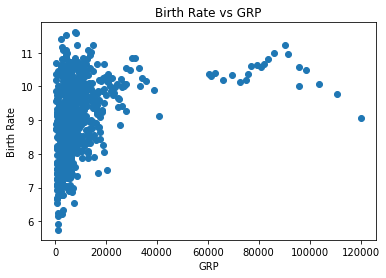

In [39]:
plt.figure()
plt.scatter(merged["GRP"], merged["birth_rate"])
plt.xlabel("GRP")
plt.ylabel("Birth Rate")
plt.title("Birth Rate vs GRP")
plt.show()

## Observation

The scatter plot shows that the data points appear compressed along the horizontal axis. This is due to the large difference in scale between the variables:

- GRP values range from a few hundred to over 100,000
- Birth rates range only between approximately 5 and 12

This large variation in GRP is expected, as GRP represents the total economic output of a region. Larger regions with higher population and economic activity naturally have much higher GRP values than smaller regions.

However, this also highlights a conceptual issue: GRP is an absolute measure, while birth rate is a relative measure (per 1,000 people). As a result, comparing these two variables directly is not meaningful.

For a more appropriate analysis, GRP per capita will be used in the following step, as it provides a normalized measure of economic output that allows for better comparison across regions.

## Using GRP per Capita for Analysis

To obtain a more meaningful comparison, GRP per capita is used instead of total GRP. This normalizes economic output by population size and allows for better comparison between regions of different sizes.

In [40]:
merged_pc = birthrate.merge(
    grp_pc,
    on=["NUTS-Code", "year"],
    how="inner"
)

print(merged_pc.head())
print(merged_pc.shape)

  NUTS-Code  year  birth_rate            Region  GRP_per_capita
0     AT111  2002       7.260  Mittelburgenland         15900.0
1     AT111  2003       6.693  Mittelburgenland         16900.0
2     AT111  2004       7.744  Mittelburgenland         17200.0
3     AT111  2005       7.265  Mittelburgenland         17800.0
4     AT111  2006       6.942  Mittelburgenland         18800.0
(770, 5)


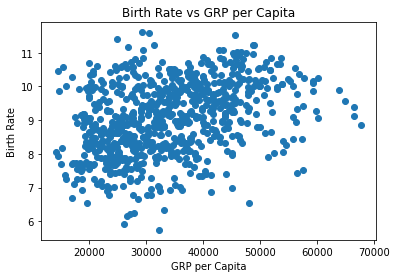

In [41]:
plt.figure()
plt.scatter(merged_pc["GRP_per_capita"], merged_pc["birth_rate"])
plt.xlabel("GRP per Capita")
plt.ylabel("Birth Rate")
plt.title("Birth Rate vs GRP per Capita")
plt.show()

In [42]:
correlation = merged_pc["birth_rate"].corr(merged_pc["GRP_per_capita"])
print("Correlation:", correlation)

Correlation: 0.3579988828395577


## Observation

The correlation between birth rate and GRP per capita is positive but moderate (approximately 0.36).

This suggests that regions with higher economic output per person tend to have slightly higher birth rates. However, the relationship is not strong, indicating that economic conditions alone do not fully explain differences in birth rates.

While there appears to be a tendency for more economically developed regions to have somewhat higher birth rates in this dataset, other factors—such as social structure, urbanization, or policy—are likely to play an important role.

Overall, GRP per capita shows some association with birth rate, but it is not a strong predictor on its own.

## Macroeconomic Trends vs. Fertility Rate Over Time

We can now leverage our consolidated National Master Dataset (`austria_master_summary`). 

In this step, we visualize the relationship between overall economic growth (Gross Regional Product) and demographic behavior. We use the **Total Fertility Rate (TFR)** instead of the Crude Birth Rate, as TFR is adjusted for age-structure and provides a much more accurate representation of actual childbearing trends.

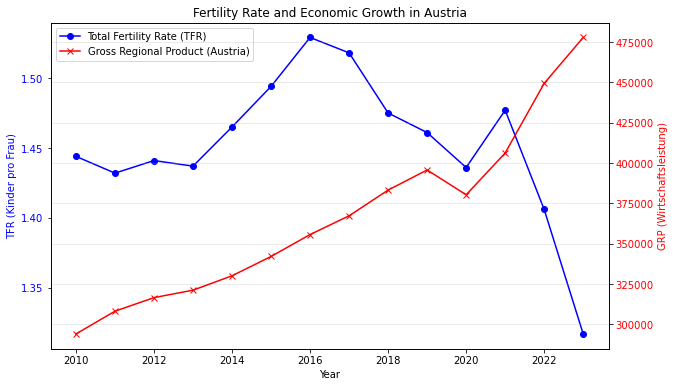

In [47]:
# Wir nutzen direkt unsere fertige Master-Tabelle!
# Kein groupby() mehr nötig.

fig, ax1 = plt.subplots(figsize=(10, 6)) # figsize macht den Plot etwas breiter und schöner

# Gesamtfertilitätsrate (TFR) auf der linken Achse
line1 = ax1.plot(
    at_master["year"],
    at_master["TFR"], # Hier nutzen wir jetzt die TFR!
    label="Total Fertility Rate (TFR)",
    color="blue",
    marker="o" # Kleine Punkte auf der Linie machen es lesbarer
)
ax1.set_xlabel("Year")
ax1.set_ylabel("TFR (Kinder pro Frau)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# GRP auf der rechten Achse
ax2 = ax1.twinx()
line2 = ax2.plot(
    at_master["year"],
    at_master["GRP"], 
    label="Gross Regional Product (Austria)",
    color="red",
    marker="x"
)
ax2.set_ylabel("GRP (Wirtschaftsleistung)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Legende zusammenfügen
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Fertility Rate and Economic Growth in Austria")
plt.grid(True, alpha=0.3) # Ein leichtes Gitter hilft beim Ablesen
plt.show()

## Housing Prices and Fertility Rate

In addition to economic output, housing prices may heavily influence demographic behavior. High housing costs can delay or affect decisions related to family formation.

Since we have already consolidated our data in the National Master Dataset, we can directly compare the **Housing Price Index (HPI)** with the **Total Fertility Rate (TFR)** over time. We calculate the correlation to see if rising housing costs are statistically associated with a decline in fertility.

In [48]:
hpi = load_collection("clean_HPI")

print(hpi.head())

   Jahr           HPI_type     HPI
0  2010  Bestehende Häuser  100.00
1  2011  Bestehende Häuser  103.65
2  2012  Bestehende Häuser  108.55
3  2013  Bestehende Häuser  112.25
4  2014  Bestehende Häuser  114.09


Correlation (Fertility Rate vs HPI): -0.4138


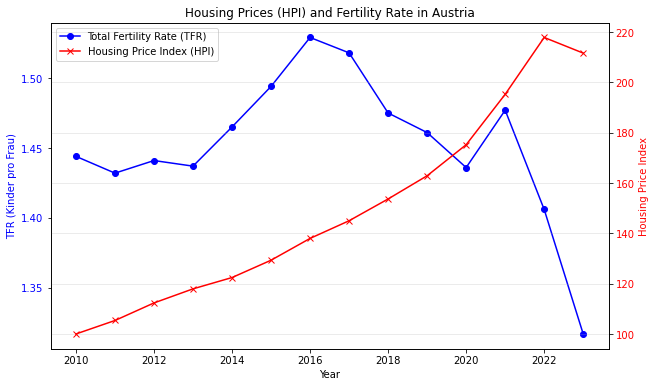

In [50]:
# Die gesamte Vorbereitung fällt weg, wir nutzen direkt unsere Master-Tabelle 'at_master'!

# 1. Korrelation berechnen (TFR vs. HPI)
hpi_corr = at_master["TFR"].corr(at_master["HPI"])
print(f"Correlation (Fertility Rate vs HPI): {hpi_corr:.4f}")

# 2. Plot erstellen
fig, ax1 = plt.subplots(figsize=(10, 6))

# TFR auf der linken Achse
line1 = ax1.plot(
    at_master["year"], 
    at_master["TFR"], 
    label="Total Fertility Rate (TFR)", 
    color="blue", 
    marker="o"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("TFR (Kinder pro Frau)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# HPI auf der rechten Achse
ax2 = ax1.twinx()
line2 = ax2.plot(
    at_master["year"], 
    at_master["HPI"], 
    label="Housing Price Index (HPI)", 
    color="red", 
    marker="x"
)
ax2.set_ylabel("Housing Price Index", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Legende zusammenführen (damit beide Linien in einer Box stehen)
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title("Housing Prices (HPI) and Fertility Rate in Austria")
plt.grid(True, alpha=0.3)
plt.show()

In [52]:
tfr_hpi_corr = at_master["TFR"].corr(at_master["HPI"])

print(f"Correlation (TFR vs HPI): {tfr_hpi_corr:.4f}")

Correlation (TFR vs HPI): -0.4138


## Observation

The time series shows that housing prices have increased steadily over the observed period, while fertility rates remain relatively stable or slightly declining.

The correlation between the Total Fertility Rate (TFR) and housing prices is moderately negative (approximately -0.41). This suggests that higher housing prices are associated with lower fertility rates.

Compared to the previous analyses using GRP and GRP per capita, this relationship is stronger. This indicates that housing costs may have a more direct influence on demographic behavior and family planning than general economic output.

However, the relationship is still not strong enough to fully explain variations in fertility rates. Other factors—such as social conditions, policies, and cultural influences—are likely also important.

Overall, housing prices appear to be a more relevant factor than general economic indicators, but not a decisive one on their own.